# Faceting, Multivariate Views, and Style

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
tips = sns.load_dataset('tips')
planets = sns.load_dataset('planets')
iris = sns.load_dataset('iris')
penguins = sns.load_dataset('penguins')
data = tips[['total_bill', 'tip']]

```{contents}
:local:
:depth: 2
```


## Figure-Level Wrappers and Faceting

These wrappers make small-multiple comparisons much easier (`row=`, `col=`, `hue=`, `height=`, `aspect=`).


### `displot()`

The `col=` is set to `time`, meaning lunch and dinner. So we get two plots automatically. 

In [ ]:
tips.head(3)

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734


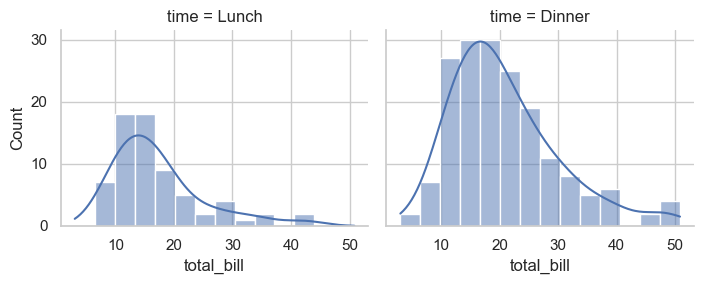

In [ ]:
sns.displot(data=tips, x='total_bill', col='time', kde=True, height=3, aspect=1.2)

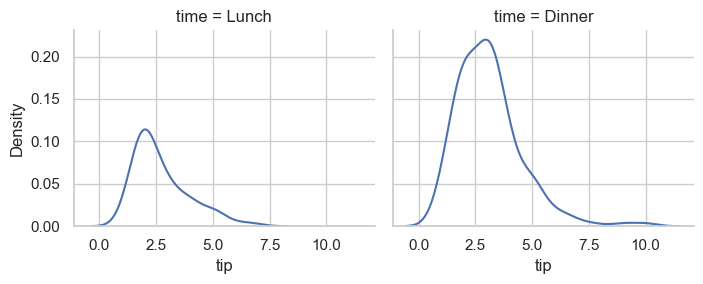

In [ ]:
sns.displot(data=tips, kind='kde', x='tip', col='time', height=3, aspect=1.2)

### `relplot()`

`relplot()` is a figure-level Seaborn function for relational data.

| Parameter | Value | Effect |
|---|---|---|
| `kind` | `'scatter'` | Uses scatter plots |
| `x`, `y` | `'total_bill'`, `'tip'` | Axes in each panel |
| `hue` | `'sex'` | Point color encodes sex |
| `col` | `'time'` | Separate columns for Lunch / Dinner |
| `row` | `'smoker'` | Separate rows for Yes / No smoker |
| `height`, `aspect` | `3`, `1` | Each facet is about 3×3 inches |


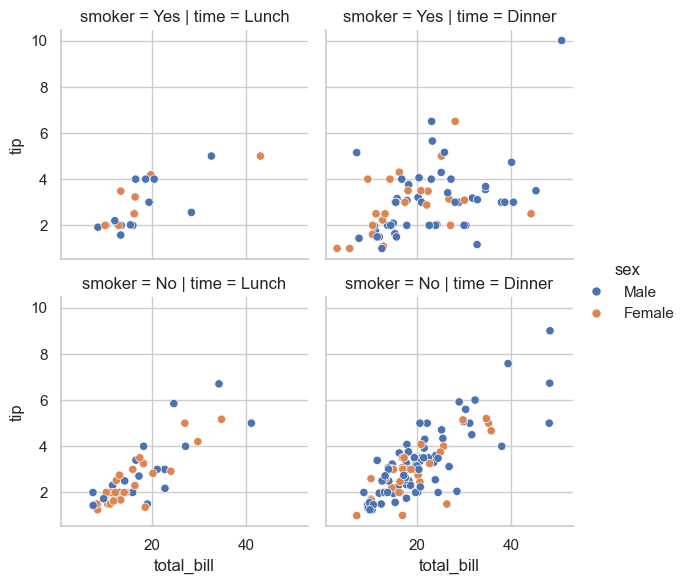

In [ ]:
sns.relplot(
    data=tips,
    x='total_bill', y='tip',
    hue='sex', col='time', row='smoker',
    kind='scatter', height=3, aspect=1
)

### `catplot()`

seaborn.axisgrid.FacetGrid

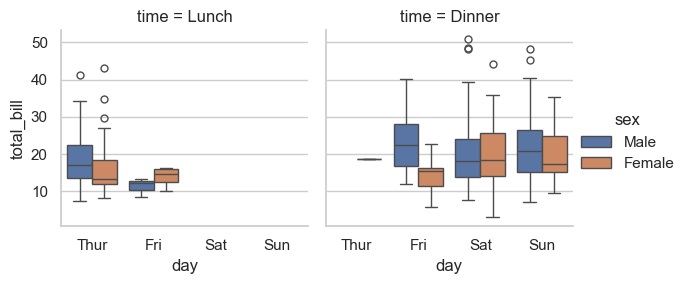

In [ ]:
cat = sns.catplot(
    data=tips,
    x='day', y='total_bill', hue='sex', col='time',
    kind='box', height=3, aspect=1
)

type(cat)

## FacetGrid

`FacetGrid` is a return type and a standalone class by itself and can be used to create a `FacetGrid` directly. 

After creating the FacetGrid, you use the `map()` function to pass plotting functions to it.

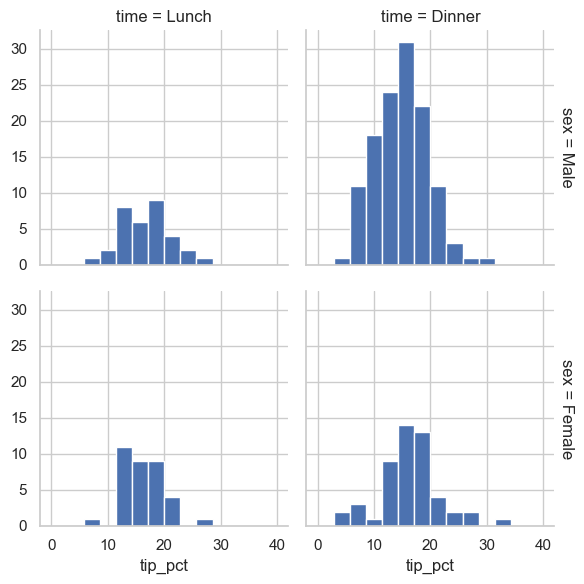

In [ ]:
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']

grid = sns.FacetGrid(data=tips, row='sex', col='time', margin_titles=True)
grid.map(plt.hist, 'tip_pct', bins=np.linspace(0, 40, 15))


**When to use FacetGrid vs. figure-level functions:**

Use `FacetGrid` when you need:
- Custom functions beyond Seaborn's built-in plots
- Multi-step plot construction (e.g., `grid.map()` multiple times)
- Fine control over individual facets

For standard faceting, `displot()`, `relplot()`, and `catplot()` are simpler and recommended.

In [ ]:
### Exercise: Faceted Tip Percentage Histograms
#   1. Create tips['tip_pct'] as 100 * tip / total_bill.
#   2. Build a FacetGrid with row='sex' and col='time'.
#   3. Map plt.hist on 'tip_pct' using bins=np.linspace(0, 40, 15).
### Your code starts here.




### Your code ends here.


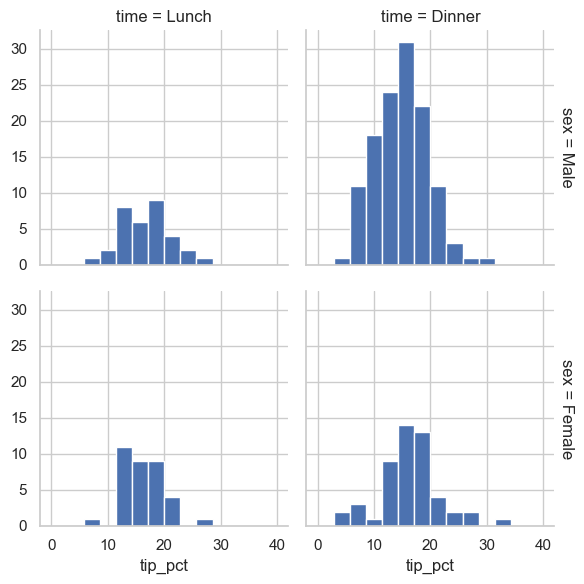

In [ ]:
### Solution
tips['tip_pct'] = 100 * tips['tip'] / tips['total_bill']
grid = sns.FacetGrid(data=tips, row='sex', col='time', margin_titles=True)
grid.map(plt.hist, 'tip_pct', bins=np.linspace(0, 40, 15))


## Multivariate Views

These plots help you inspect relationships among multiple variables at once.


### Pair Plots

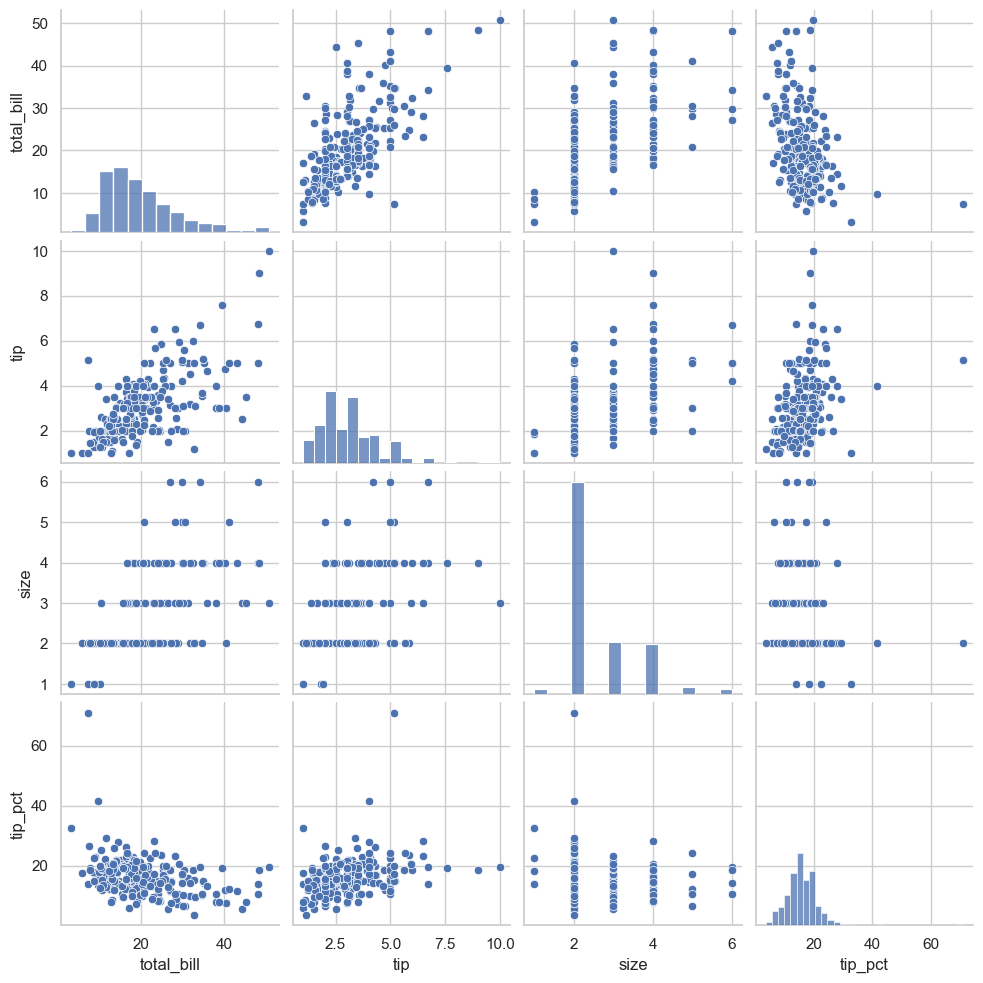

In [ ]:
sns.pairplot(tips)

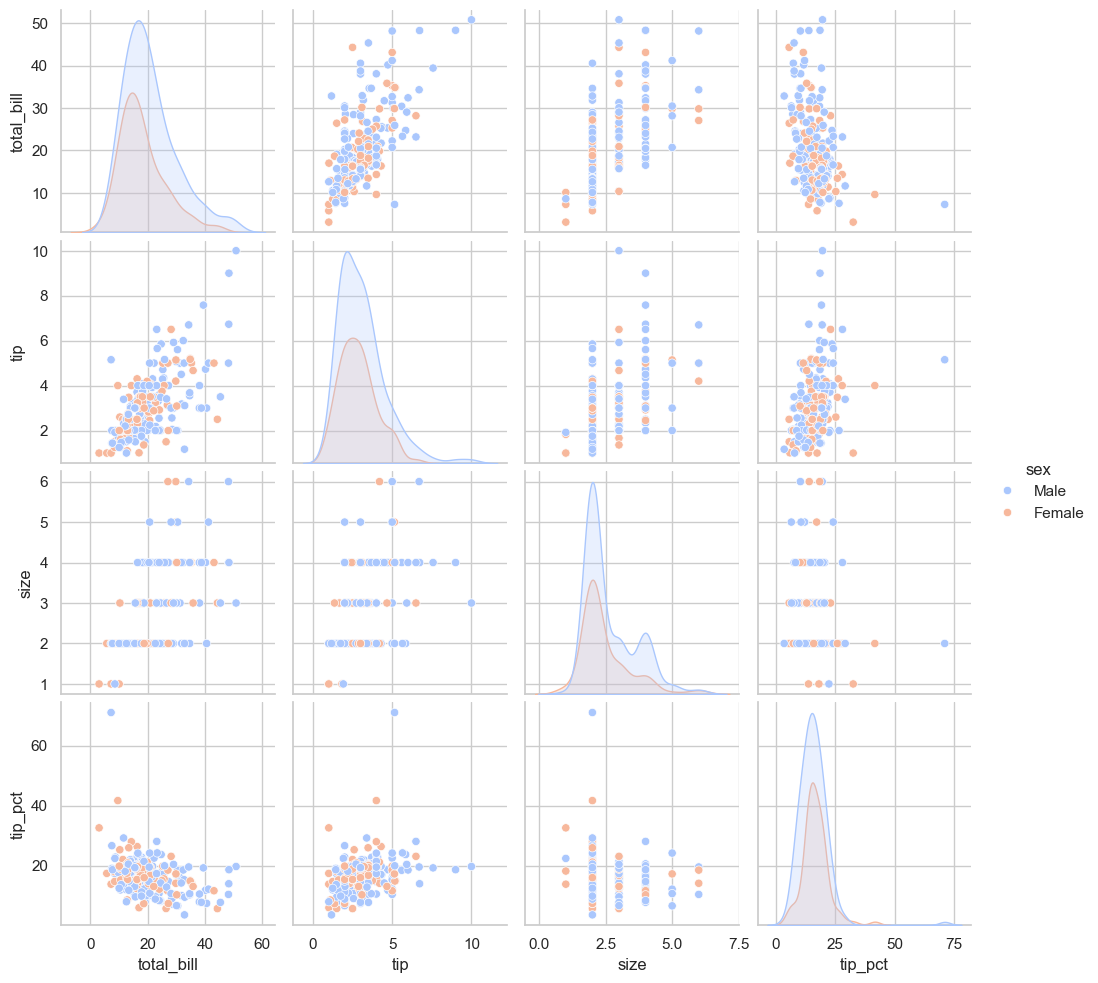

In [ ]:
sns.pairplot(tips, hue='sex', palette='coolwarm')

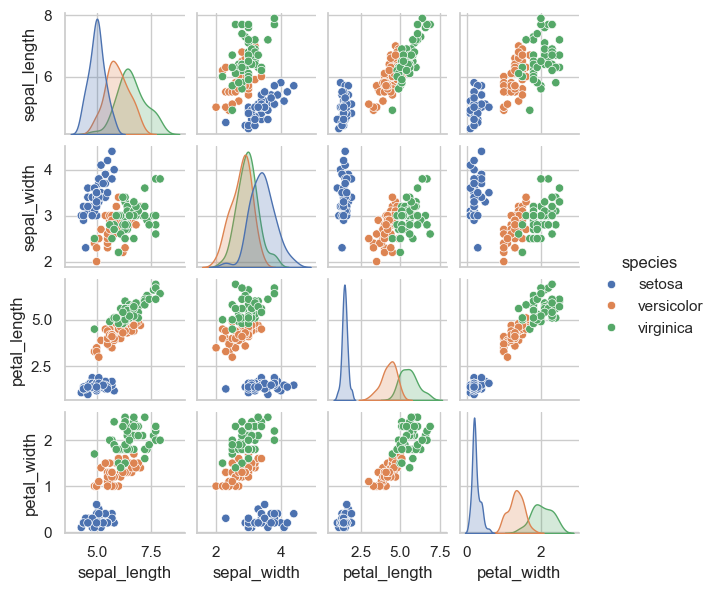

In [ ]:
sns.pairplot(iris, hue='species', height=1.5)

In [ ]:
### Exercise: Pairplot with Group Coloring
#   1. Create a pairplot using the iris dataset.
#   2. Color points by species using hue='species'.
#   3. Set height=1.5 for each subplot.
### Your code starts here.




### Your code ends here.


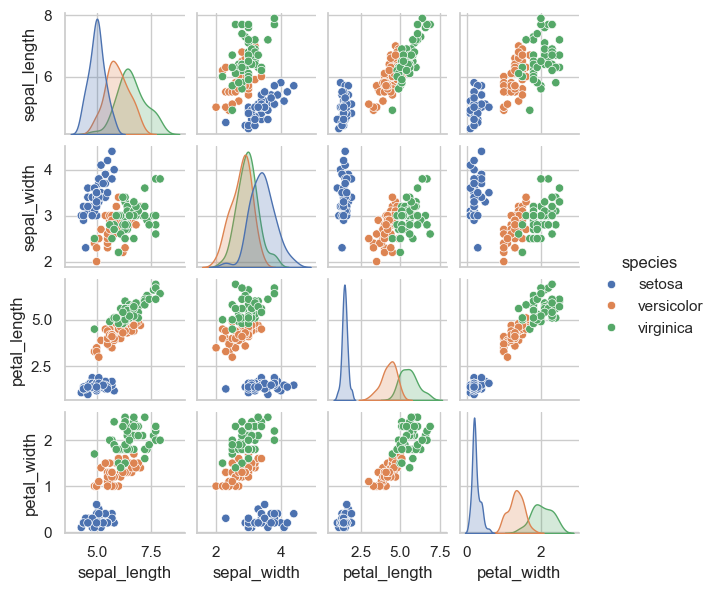

In [ ]:
### Solution
sns.pairplot(iris, hue='species', height=1.5)


### Joint Plots

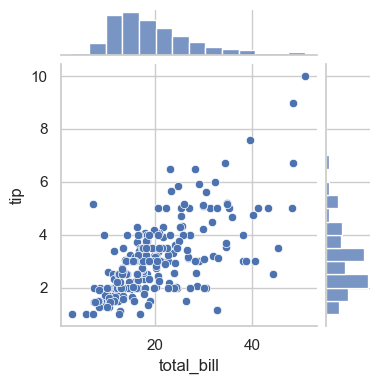

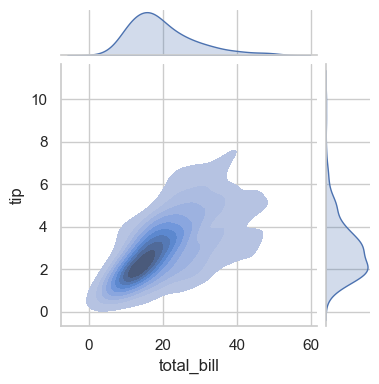

In [59]:
### you may be tempted to do this, but it won't work because sns.jointplot creates its own figure and axes
# fig, ax = plt.subplots(1, 2, figsize=(8, 3))
# sns.jointplot(data=tips, x='total_bill', y='tip', kind='scatter', ax=ax[0])
# sns.jointplot(data=tips, x='total_bill', y='tip', kind='kde', fill=True, ax=ax[1])
###

sns.jointplot(data=tips, x='total_bill', y='tip', kind='scatter', height=4)
sns.jointplot(data=tips, x='total_bill', y='tip', kind='kde', fill=True, height=4)

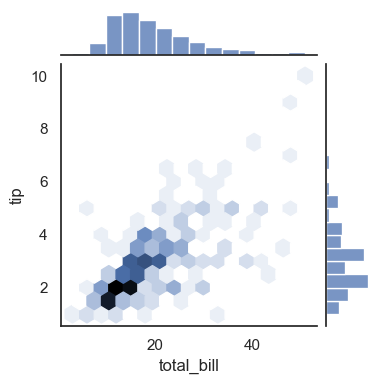

In [62]:
with sns.axes_style('white'):
    sns.jointplot(data=tips, kind='hex', x='total_bill', y='tip', height=4)


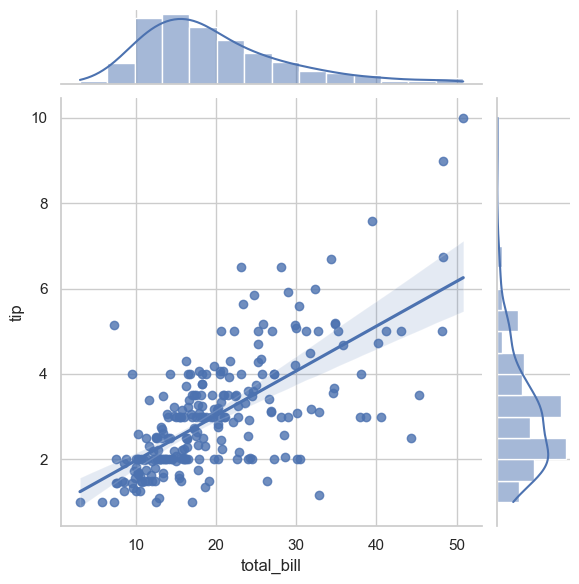

In [ ]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='reg')

In [ ]:
### Exercise: Joint Plot with Regression
#   1. Create a joint plot of total_bill vs tip from tips.
#   2. Use kind='reg'.
#   3. Keep default marginal distributions.
### Your code starts here.




### Your code ends here.


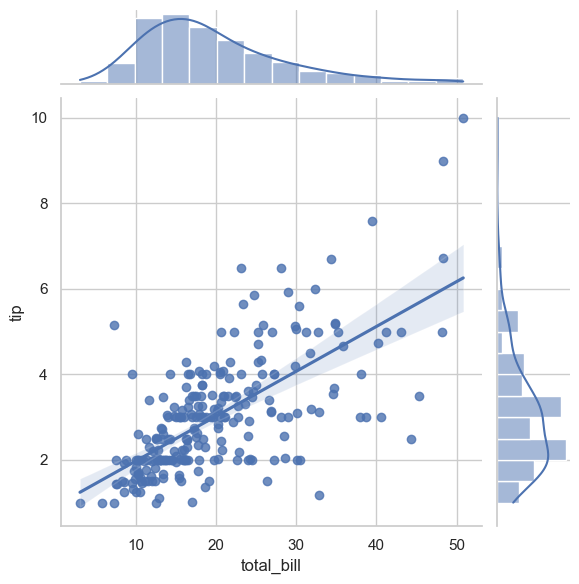

In [ ]:
### Solution
sns.jointplot(x='total_bill', y='tip', data=tips, kind='reg')


### Heatmap (Common EDA Pattern)

Heatmaps are useful for compact matrix-style summaries, such as correlation matrices.


Text(0.5, 1.0, 'Correlation Heatmap')

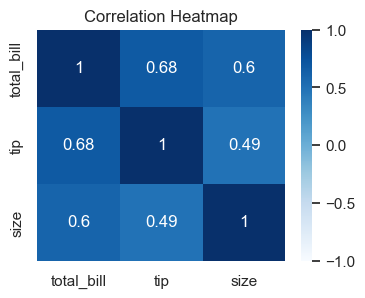

In [ ]:
corr = tips[['total_bill', 'tip', 'size']].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Heatmap')


In [ ]:
### Exercise: Correlation Heatmap
#   1. Compute a correlation matrix from ['total_bill', 'tip', 'size'].
#   2. Plot a heatmap with annot=True and cmap='Blues'.
#   3. Set vmin=-1 and vmax=1.
#   4. Add title 'Tips Correlation Heatmap'.
### Your code starts here.




### Your code ends here.


Text(0.5, 1.0, 'Tips Correlation Heatmap')

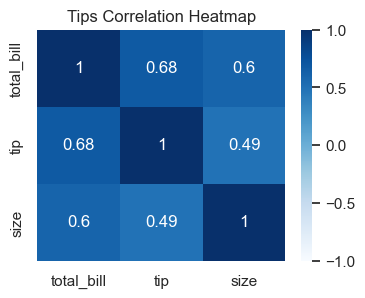

In [ ]:
### Solution
corr = tips[['total_bill', 'tip', 'size']].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1, ax=ax)
ax.set_title('Tips Correlation Heatmap')


## Themes and Global Style

Seaborn theme settings apply globally in the notebook and help keep plots visually consistent.


<Axes: xlabel='total_bill', ylabel='tip'>

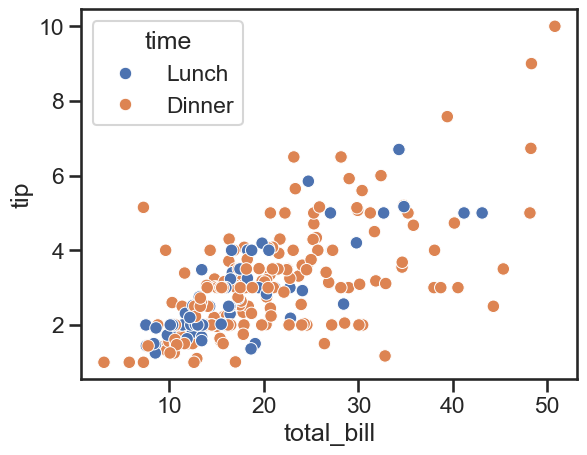

In [ ]:
sns.set_theme(style='ticks', context='talk', palette='deep')
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time')


In [64]:
# Reset to a moderate default for the rest of your work
sns.set_theme(style='whitegrid', context='notebook')


To list all named palettes:

In [65]:
print(dir(sns.palettes))

['MPL_QUAL_PALS', 'QUAL_PALETTES', 'QUAL_PALETTE_SIZES', 'SEABORN_PALETTES', '_ColorPalette', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_color_to_rgb', '_parse_cubehelix_args', '_patch_colormap_display', 'blend_palette', 'color_palette', 'colorsys', 'crayon_palette', 'crayons', 'cubehelix_palette', 'cycle', 'dark_palette', 'desaturate', 'diverging_palette', 'get_color_cycle', 'get_colormap', 'hls_palette', 'husl', 'husl_palette', 'light_palette', 'mpl', 'mpl_palette', 'np', 'set_color_codes', 'xkcd_palette', 'xkcd_rgb']


The commonly used built-in options are:

**Qualitative** (good for categories)
```
'deep', 'muted', 'pastel', 'bright', 'dark', 'colorblind'
```
**Sequential**
```
'Blues', 'Greens', 'Reds', 'Oranges', 'Purples', 'Greys'
```
**Diverging**
```
'coolwarm', 'RdBu', 'BrBG', 'PiYG'
```
**Perceptually uniform**
```
'viridis', 'plasma', 'magma', 'inferno', 'cividis'
```

To visually browse all palettes (most useful):

In [85]:
# See a single palette
sns.color_palette('deep')
# sns.color_palette('muted')

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [78]:
# Show a visual swatch in Jupyter
sns.palettes.SEABORN_PALETTES  # dict of all seaborn palettes

{'deep': ['#4C72B0',
  '#DD8452',
  '#55A868',
  '#C44E52',
  '#8172B3',
  '#937860',
  '#DA8BC3',
  '#8C8C8C',
  '#CCB974',
  '#64B5CD'],
 'deep6': ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974', '#64B5CD'],
 'muted': ['#4878D0',
  '#EE854A',
  '#6ACC64',
  '#D65F5F',
  '#956CB4',
  '#8C613C',
  '#DC7EC0',
  '#797979',
  '#D5BB67',
  '#82C6E2'],
 'muted6': ['#4878D0', '#6ACC64', '#D65F5F', '#956CB4', '#D5BB67', '#82C6E2'],
 'pastel': ['#A1C9F4',
  '#FFB482',
  '#8DE5A1',
  '#FF9F9B',
  '#D0BBFF',
  '#DEBB9B',
  '#FAB0E4',
  '#CFCFCF',
  '#FFFEA3',
  '#B9F2F0'],
 'pastel6': ['#A1C9F4', '#8DE5A1', '#FF9F9B', '#D0BBFF', '#FFFEA3', '#B9F2F0'],
 'bright': ['#023EFF',
  '#FF7C00',
  '#1AC938',
  '#E8000B',
  '#8B2BE2',
  '#9F4800',
  '#F14CC1',
  '#A3A3A3',
  '#FFC400',
  '#00D7FF'],
 'bright6': ['#023EFF', '#1AC938', '#E8000B', '#8B2BE2', '#FFC400', '#00D7FF'],
 'dark': ['#001C7F',
  '#B1400D',
  '#12711C',
  '#8C0800',
  '#591E71',
  '#592F0D',
  '#A23582',
  '#3C3C3C',
  '#B8850A

In [79]:
# Or use matplotlib's colormaps too
import matplotlib.pyplot as plt
plt.colormaps()  # lists all matplotlib-compatible names

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

## Why KDE Looks Smooth

This section is optional and focuses on intuition for KDE construction.


`rugplot` marks each observation on one axis. A KDE can be viewed as the sum of many smooth kernels centered on those observations.

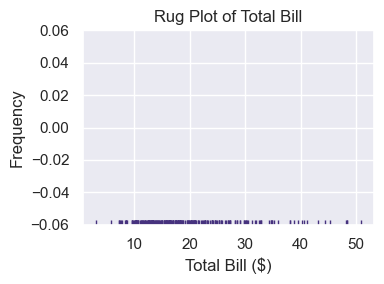

In [68]:
sns.set_theme(palette='viridis')

ax = sns.rugplot(tips['total_bill'])
ax.set_title('Rug Plot of Total Bill')
ax.set_xlabel('Total Bill ($)')
ax.set_ylabel('Frequency')

ax.figure.set_size_inches(4, 3)
plt.tight_layout()

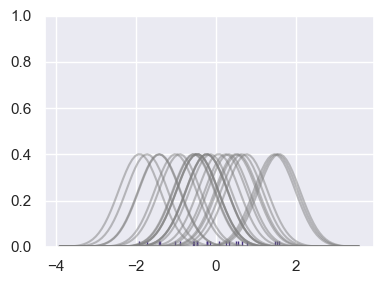

In [69]:
# Don't worry about understanding this code in depth.
# It visualizes how summing basis functions forms a KDE-like curve.
from scipy import stats

# Create dataset
np.random.seed(42)
dataset = np.random.randn(25)

ax = sns.rugplot(dataset)

x_min = dataset.min() - 2
x_max = dataset.max() + 2
x_axis = np.linspace(x_min, x_max, 100)

bandwidth = ((4 * dataset.std()**5) / (3 * len(dataset)))**.2

kernel_list = []
for data_point in dataset:
    kernel = stats.norm(data_point, bandwidth).pdf(x_axis)
    kernel_list.append(kernel)

    kernel = kernel / kernel.max()
    kernel = kernel * .4
    plt.plot(x_axis, kernel, color='grey', alpha=0.5)

plt.ylim(0, 1)

ax.figure.set_size_inches(4, 3)
plt.tight_layout()

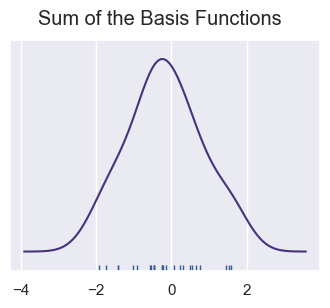

In [70]:
sum_of_kde = np.sum(kernel_list, axis=0)
plt.figure(figsize=(4, 3))
plt.plot(x_axis, sum_of_kde)
sns.rugplot(dataset)
plt.yticks([])
plt.suptitle('Sum of the Basis Functions');

## Styling

In [71]:
sns.set_theme(style='whitegrid', context='notebook')

### Size

The `size=` and `s=` parameters are different parameters. 

- `size=` is not a parameter, it's for semantic mapping. For example, `size='size'` maps `size` from data column size.
- `s=` sets constant size across all points.
  



sns.scatterplot(data=tips, x=`total_bill`, y=`tip`, `s=100`)

sns.scatterplot(data=tips, x=`total_bill`, y=`tip`, `size='size'`)

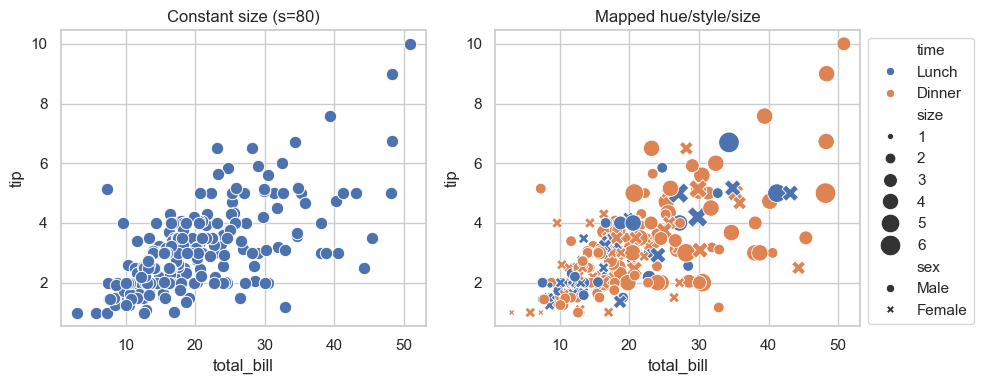

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# constant size points
sns.scatterplot(data=tips, x='total_bill', y='tip', s=80, ax=ax[0])
ax[0].set_title('Constant size (s=80)')

# size mapped from a real numeric column in the dataframe
sns.scatterplot(
    data=tips, x='total_bill', y='tip',
    hue='time', style='sex', size='size', sizes=(20, 220),
    ax=ax[1]
)
ax[1].set_title('Mapped hue/style/size')
ax[1].legend(bbox_to_anchor=(1, 1))  ### move legend outside the plot

plt.tight_layout()


### Alpha

Seaborn's `histplot()` intelligently applies transparency when plotting multiple overlapping distributions. It detects overlapping series and applies transparency automatically so both are visible—one of Seaborn's key advantages over Pandas and Matplotlib.

- **Pandas** `plot(kind="hist")` — overlaps with no transparency, you must set `alpha=` manually
- **Matplotlib** `ax.hist()` — same, manual `alpha=` required
- **Seaborn** `histplot()` — handles transparency automatically for overlapping series

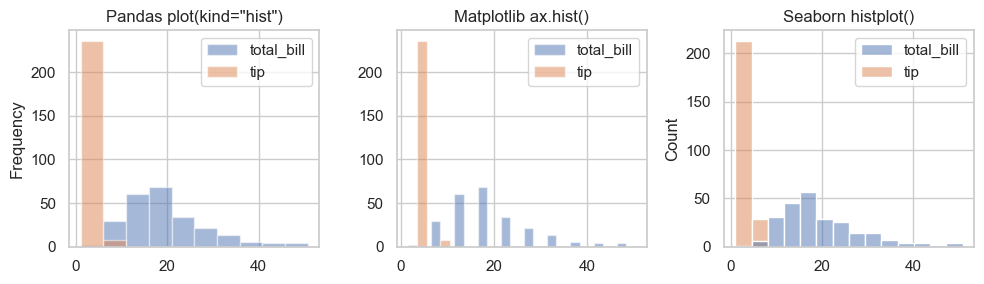

In [73]:
data = tips[['total_bill', 'tip']]

fig, ax = plt.subplots(1, 3, figsize=(10, 3))

### Pandas histogram
data.plot(ax=ax[0], kind='hist', title='Pandas plot(kind="hist")', alpha=0.5)

### Matplotlib histogram
ax[1].hist(data, label=['total_bill', 'tip'], alpha=0.5)
ax[1].set_title('Matplotlib ax.hist()')
ax[1].legend()

### Seaborn histogram
sns.histplot(data=data, ax=ax[2])
ax[2].set_title('Seaborn histplot()')

plt.tight_layout()


### Overlay

**When combining multiple plot types**, axes-level functions give you full control. On the other hand, figure-level functions create their own figure, making layering harder. Note that the three plots are all rendered on the same MPL axes object (`ax`). 

`ax.axhline()` adds a horizontal line spanning the whole or fraction of the Axes. (see [matplotlib.pyplot.axhline](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html)). The basic syntax of `axhline()` is:

```python
ax.axhline(y=0, xmin=0, xmax=1, **kwargs)
```

Commonly used parameters for `ax.axhlin()` include:
| Parameter  | Meaning                         |
| ---------- | ------------------------------------------------------ |
| `y`       | y-value where the horizontal line is drawn         |
| `xmin`   | start of the line (fraction of axis width, 0–1)        |
| `xmax`     | end of the line (fraction of axis width, 0–1)      |
| `**kwargs` | styling options like `color`, `linestyle`, `linewidth`|


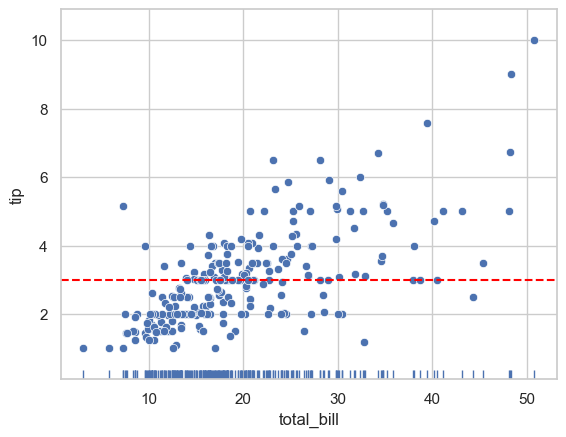

In [ ]:
fig, ax = plt.subplots()
sns.scatterplot(data=tips, x='total_bill', y='tip', ax=ax)
sns.rugplot(data=tips, x='total_bill', ax=ax)                   # Add rug marks
ax.axhline(y=tips['tip'].mean(), color='red', linestyle='--')   # Add reference 